In [1]:
import VESIcal as v
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm 
import warnings
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

In [2]:
warnings.filterwarnings('ignore')

In [3]:
def normalize_sample(smpl):
    total=0
    for i in range(len(smpl)): 
        total += smpl[i]
    
    for i in range(len(smpl)): 
        smpl[i] = 100*smpl[i] / total
    
    return smpl 

In [4]:
def normalize_sample_fixed(smpl, fixed=("H2O","CO2")):
    smpl = smpl.copy()

    mask = ~smpl.index.isin(fixed)

    remaining_total = 100 - smpl.loc[list(fixed)].sum()

    smpl.loc[mask] *= remaining_total / smpl.loc[mask].sum()

    return smpl

In [5]:
def smooth_fcn(v, limit): 
    vc = v.copy() 
    for i in range(len(vc)-2): 
        if abs(vc[i+1]-vc[i]) > limit: 
            vc[i+1] = v[i] 
    return vc

In [6]:
def smooth_join(v, center, window=10):
    vc = v.copy()

    start = max(center - window, 0)
    end = min(center + window, len(v))

    segment = vc[start:end]

    for i in range(1, len(segment)-1):
        segment[i] = np.median(segment[i-1:i+2])

    vc[start:end] = segment
    return vc

In [7]:
def fit_func(x, a, b, c):
    return a * np.exp(b * x) + c

In [28]:
g = 9.8
rhor = 2550
denom = 10**3 /(g*rhor)

In [29]:
myfile = v.BatchFile('usgs_kilaueachemistry_all.csv')
data = myfile.get_data()
data.pop('Cl')
data.pop('F ')
data = data.drop(index=data.index[9])
data

,SiO2,Al2O3,Fe2O3,FeO,MgO,CaO,Na2O,K2O,H2O,TiO2,P2O5,MnO,CO2
57F-18,49.63,13.76,3.69,9.31,5.80,10.23,2.74,0.61,0.28,3.49,0.35,0.19,0.02
57F-15,48.53,11.15,1.15,10.71,15.17,8.94,1.76,0.33,0.17,1.91,0.18,0.18,0.01
57F-17,49.40,12.46,1.51,10.25,10.96,10.32,2.05,0.38,0.26,2.21,0.22,0.18,0.02
57F-66,50.59,13.20,1.49,9.92,8.38,10.88,2.19,0.39,0.36,2.40,0.23,0.18,0.02
55F-97,50.77,13.46,2.07,9.24,8.14,10.76,2.23,0.38,0.08,2.51,0.24,0.17,0.02
53P-12,50.98,13.75,3.38,8.04,7.18,11.17,2.34,0.43,0.06,2.52,0.23,0.17,0.00
53P-32,50.52,13.82,3.58,7.90,7.13,11.12,2.20,0.44,0.32,2.65,0.23,0.17,0.01
53P-33,50.73,13.74,1.83,9.45,7.23,11.22,2.20,0.46,0.16,2.62,0.22,0.17,0.01
53P-35,50.94,14.04,2.67,8.20,7.24,11.29,2.23,0.40,0.15,2.46,0.21,0.16,0.00
HIGS-2,51.52,14.10,1.70,9.28,6.79,10.92,2.34,0.42,0.11,2.37,0.23,0.17,0.02


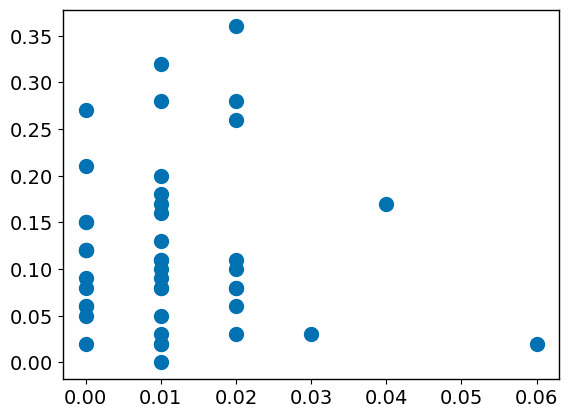

In [30]:
plt.scatter(data.CO2, data.H2O)

In [31]:
T = 1350
step = 50

In [32]:
R = 8.314 
T_K = T + 273.15 
M_H2O = 0.018  
M_CO2 = 0.044  
degassed_rho = 3000

H2OT0 = 350 
H2OM0 = 1.12*10**(-5) 
H2OS = 1064
CO2T0 = 273 
CO2M0 = 1.370*10**(-5) 
CO2S = 222

# for multiple samples 
paths = [] 
gd = [] 
gv = [] 
mds = [] 
mvs = [] 
volfracs = [] 
efds = [] 
efvs = [] 

for idx in range(15, 20): #range(data.shape[0]): 
    sample_name = data.index[idx]
    my_sample = myfile.get_sample_composition(sample_name, asSampleClass=True)
    
    # calculate degassing paths 
    p = v.calculate_degassing_path(sample=my_sample, steps=step, final_pressure=0.1, fraction_vapor=0.5, temperature=T).result
    paths.append(p) 
    
    sample_evo = pd.DataFrame(columns=data.columns)
    smpl = data.iloc[idx]
    
    meltvs = [] 
    meltds = [] 
    gasvs = [] 
    gasds = [] 
    vfs = [] 
    effect_den = [] 
    effect_vis = [] 
    
    for j in range(len(p.Pressure_bars)): 
        smpl['H2O'] = p.H2O_liq[j]
        smpl['CO2'] = p.CO2_liq[j]
        smpl = normalize_sample_fixed(smpl)
        sample_evo.loc[j] = smpl 

        # melt parameters 
        smp = v.Sample(smpl)
        md = v.calculate_liquid_density(sample=smp, temperature=T, pressure=p.Pressure_bars[j]).result
        mv = v.calculate_liquid_viscosity(sample=smp, temperature=T).result

        meltds.append(md)
        meltvs.append(mv)

        # gas parameters 
        M_mean = p.XH2O_fl[j]*M_H2O + p.XCO2_fl[j]*M_CO2
        rho = (10**6*p.Pressure_bars[j]) * M_mean / (R * T_K)
        gasds.append(rho)
        H2OM = H2OM0*((H2OT0+H2OS)/(T_K+H2OS))*(T_K/H2OT0)
        CO2M = CO2M0*((CO2T0+CO2S)/(T_K+CO2S))*(T_K/CO2T0)
        mu =  p.XH2O_fl[j]*H2OM + p.XCO2_fl[j]*CO2M
        gasvs.append(mu)

        # volume fraction 
        vf = (rho/p.FluidProportion_wt[j]) / ((rho/p.FluidProportion_wt[j]) + (md/(1-p.FluidProportion_wt[j])))
        vfs.append(vf)

        # effective parameters 
        effect_den.append(vf*rho + (1-vf)*md)
        # effect_vis.append(vf*mu + (1-vf)*mv)
        effect_vis.append(mv)
    vfs.reverse() 
    effect_den.reverse() 
    effect_vis.reverse() 
    
    gd.append(gasds) 
    gv.append(gasvs)
    mds.append(meltds) 
    mvs.append(meltvs) 
    volfracs.append(vfs)  
    efds.append(effect_den)
    efvs.append(effect_vis) 

[====================] 100% Calculating degassing path...
[====================] 100% Calculating degassing path...
[====================] 100% Calculating degassing path...
[====================] 100% Calculating degassing path...
[====================] 100% Calculating degassing path...


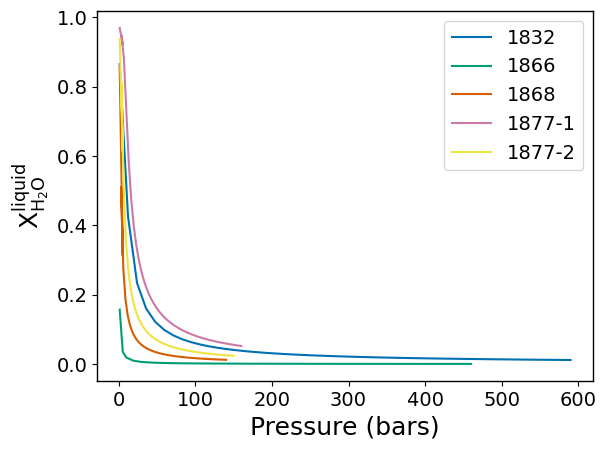

In [33]:
for i in range(len(efds)): 
    plt.plot(paths[i].Pressure_bars, paths[i].XH2O_fl, label=data.index[i+15])
plt.ylabel(r"$X_{H_2O}^{liquid}$")
plt.xlabel("Pressure (bars)")
plt.legend()

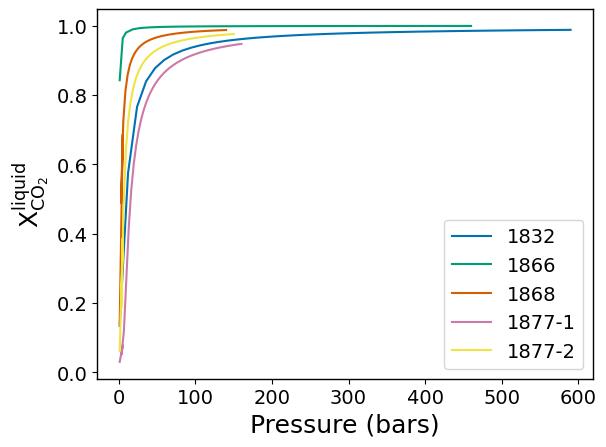

In [34]:
for i in range(len(efds)): 
    plt.plot(paths[i].Pressure_bars, paths[i].XCO2_fl, label=data.index[i+15])
plt.ylabel(r"$X_{CO_2}^{liquid}$")
plt.xlabel("Pressure (bars)")
plt.legend()

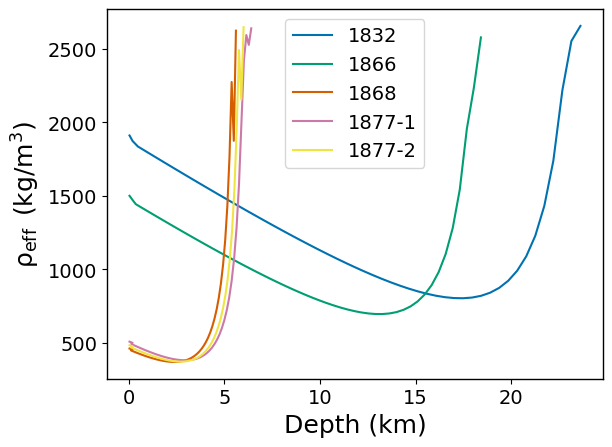

In [35]:
for i in range(len(efds)): 
    normalized = paths[i].Pressure_bars*denom
    plt.plot(paths[i].Pressure_bars*denom, np.array(efds[i]), label=data.index[i+15])
plt.xlabel("Depth (km)")
plt.ylabel(r"$\rho_{eff} \, \, \, (kg/m^3)$")
plt.legend()

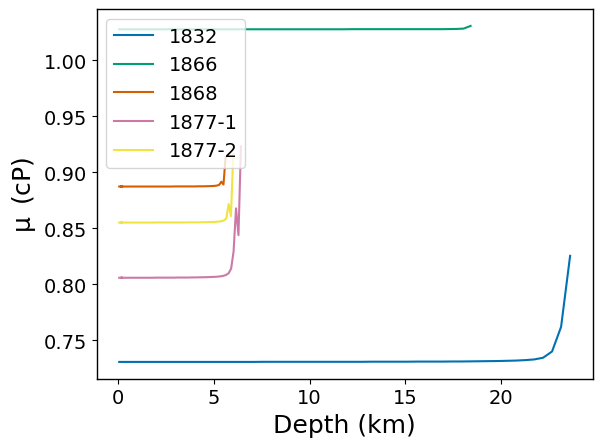

In [36]:
for i in range(len(efds)): 
    normalized = paths[i].Pressure_bars*denom
    plt.plot(paths[i].Pressure_bars*denom, np.array(efvs[i]), label=data.index[i+15])
plt.xlabel("Depth (km)")
plt.ylabel(r"$\mu \, \, \, (cP)$")
plt.legend(loc='upper left')

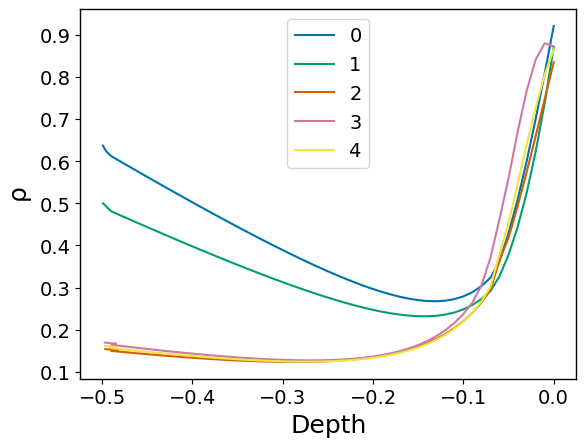

In [37]:
for i in range(len(efds)): 
    normalized = ((paths[i].Pressure_bars*denom)/(2*max((paths[i].Pressure_bars*denom))))
    plt.plot(normalized - 0.5*np.ones(len(paths[i].Pressure_bars)), savgol_filter(np.array(efds[i])/3000, window_length=11, polyorder=3), label=i)
plt.xlabel("Depth")
plt.ylabel(r"$\rho$")
plt.legend()

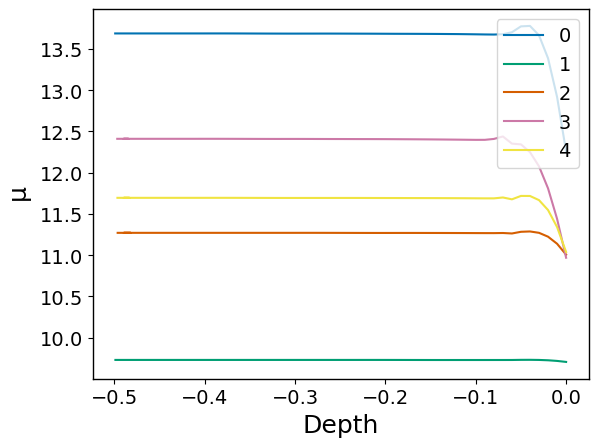

In [38]:
for i in range(len(efds)): 
    normalized = ((paths[i].Pressure_bars*denom)/(2*max((paths[i].Pressure_bars*denom))))
    plt.plot(normalized - 0.5*np.ones(len(paths[i].Pressure_bars)), 10/savgol_filter(np.array(efvs[i]), window_length=11, polyorder=3), label=i)
plt.xlabel("Depth")
plt.ylabel(r"$\mu$")
plt.legend()

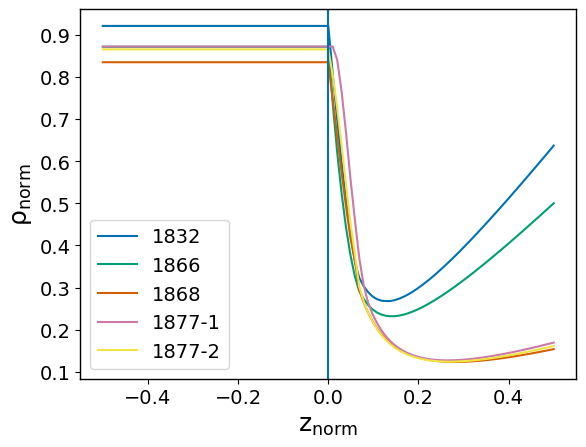

In [41]:
rho_profiles = {}
all_profiles = []

for i in range(len(efds)):
    normalized = savgol_filter(np.array(efds[i])/3000, window_length=11, polyorder=3)
    atdepth_value = normalized[0]
    atdepth = atdepth_value * np.ones(len(paths[i].Pressure_bars))
    
    # Find the index in normalized[1:] that's closest to atdepth_value
    differences = np.abs(normalized[1:] - atdepth_value)
    best_join_idx = np.argmin(differences) + 1  # +1 because we searched from index 1
    
    # Concatenate at the best matching point (skipping the duplicate region)
    total_rho = np.concatenate((atdepth, normalized[best_join_idx:]))
    
    # Smooth the join
    join_idx = len(atdepth)
    total_rho = smooth_join(total_rho, join_idx, window=15)
    
    all_profiles.append(total_rho)

# Make all profiles the same length
max_len = max(len(p) for p in all_profiles)

for i, p in enumerate(all_profiles):
    if len(p) < max_len:
        pad = np.full(max_len - len(p), p[-1])   # repeat last value
        p = np.concatenate((p, pad))
    all_profiles[i] = p
    rho_profiles[data.index[i+15]] = p

x = np.linspace(-0.5, 0.5, num=max_len)
rho_profiles = pd.DataFrame(rho_profiles, index=x)

for i in range(rho_profiles.shape[1]): 
    plt.plot(rho_profiles.index, rho_profiles.loc[:,data.index[i+15]], label=data.index[i+15])
plt.axvline(0)
plt.ylabel(r"$\rho_{norm}$")
plt.xlabel(r"$z_{norm}$")
plt.legend()

# save the df 
rho_profiles.to_csv("rhoprofiles_1to5_030926.csv")

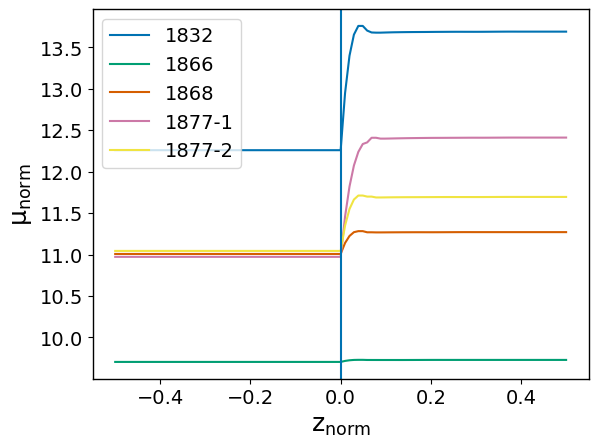

In [42]:
mu_profiles = {}
all_profiles_mu = []

for i in range(len(efvs)):
    normalized = savgol_filter(10/np.array(efvs[i]), window_length=11, polyorder=3)
    atdepth_value = normalized[0]
    atdepth = atdepth_value * np.ones(len(paths[i].Pressure_bars))
    
    # Find the index in normalized[1:] that's closest to atdepth_value
    differences = np.abs(normalized[1:] - atdepth_value)
    best_join_idx = np.argmin(differences) + 1  # +1 because we searched from index 1
    
    # Concatenate at the best matching point (skipping the duplicate region)
    total_mu = np.concatenate((atdepth, normalized[best_join_idx:]))
    
    # Smooth the join
    join_idx = len(atdepth)
    total_mu = smooth_join(total_mu, join_idx, window=15)

    all_profiles_mu.append(total_mu)

max_len = max(len(p) for p in all_profiles_mu)

for i, p in enumerate(all_profiles_mu):
    if len(p) < max_len:
        pad = np.full(max_len - len(p), p[-1])   # repeat last value
        p = np.concatenate((p, pad))
    all_profiles_mu[i] = p  # Update the list
    mu_profiles[data.index[i+15]] = p

x = np.linspace(-0.5, 0.5, num=max_len)
mu_profiles = pd.DataFrame(mu_profiles, index=x)

for i in range(mu_profiles.shape[1]): 
    plt.plot(mu_profiles.index, mu_profiles.loc[:,data.index[i+15]], label=data.index[i+15])
# plt.axvline(0)
plt.axvline(0)
plt.ylabel(r"$\mu_{norm}$")
plt.xlabel(r"$z_{norm}$")
plt.legend()

# save the df 
mu_profiles.to_csv("muprofiles_1to5_030926.csv")